### Описание системы
Рассматривается колл-центр с одним оператором, в который поступают два класса звонков:

- высокоприоритетные звонки;
- низкоприоритетные звонки.

Потоки звонков обоих классов являются пуассоновскими.  
Время обслуживания одного звонка имеет экспоненциальное распределение.  
Используется абсолютный приоритет: после освобождения оператора в первую очередь выбирается звонок высокого приоритета.  
Если в системе находятся только низкоприоритетные звонки, то обслуживается первый из них.  
Начатое обслуживание не прерывается.

Система относится к классу M/M/1 с двумя классами заявок и абсолютным приоритетом.

### Параметры модели

- $\lambda_1$ — интенсивность поступления высокоприоритетных звонков;
- $\lambda_2$ — интенсивность поступления низкоприоритетных звонков;
- $\mu$ — интенсивность обслуживания;
- $T$ — длительность моделирования;
- $N_{\text{runs}}$ — число независимых запусков модели.

### Основные формулы

Полная интенсивность входящего потока:
$$
\lambda = \lambda_1 + \lambda_2
$$

Коэффициенты загрузки:
$$
\rho_1 = \frac{\lambda_1}{\mu}, \quad \rho_2 = \frac{\lambda_2}{\mu}, \quad \rho = \rho_1 + \rho_2 = \frac{\lambda_1 + \lambda_2}{\mu}
$$

Для устойчивости системы должно выполняться условие:
$$
\rho < 1
$$

Для одноканальной системы с абсолютным приоритетом без прерывания обслуживания:
$$
W_0 = \frac{\lambda_1 + \lambda_2}{\mu^2}
$$

Среднее время ожидания в очереди для высокоприоритетных звонков:
$$
W_{q1} = \frac{W_0}{1 - \rho_1}
$$

Среднее время ожидания в очереди для низкоприоритетных звонков:
$$
W_{q2} = \frac{W_0}{(1 - \rho)(1 - \rho_1)}
$$

Среднее время пребывания в системе:
$$
W_1 = W_{q1} + \frac{1}{\mu}
$$

$$
W_2 = W_{q2} + \frac{1}{\mu}
$$

Вероятность того, что поступившая заявка будет ждать:
$$
P(\text{wait}) = \rho
$$

Среднее число заявок в системе:
$$
L = \lambda_1 W_1 + \lambda_2 W_2
$$

### Алгоритм работы модели

1. Задаются параметры системы: $\lambda_1$, $\lambda_2$, $\mu$, $T$, $N_{\text{runs}}$.
2. Формируются два независимых потока звонков: высокого и низкого приоритета.
3. Если оператор свободен, звонок сразу идет на обслуживание.
4. Если оператор занят, звонок становится в очередь своего класса.
5. После завершения обслуживания сначала выбирается звонок высокого приоритета, затем низкого.
6. В ходе моделирования собирается статистика по каждому классу заявок:
   - среднее время ожидания;
   - среднее время пребывания в системе;
   - вероятность ожидания.
7. Также вычисляются общие характеристики системы:
   - коэффициент загрузки;
   - среднее число заявок в системе.
8. Моделирование повторяется многократно.
9. Итоговые показатели определяются усреднением по всем запускам.
10. Далее анализируется влияние интенсивности потока на время ожидания для каждого класса заявок.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lambda_high = 3
lambda_low = 5
mu_service = 10
simulation_time = 1000
n_runs = 200

In [3]:
def simulate_priority_call_center(lambda_high, lambda_low, mu_service, simulation_time, random_state=None):
    rng = np.random.default_rng(random_state)

    next_high = rng.exponential(1 / lambda_high) if lambda_high > 0 else np.inf
    next_low = rng.exponential(1 / lambda_low) if lambda_low > 0 else np.inf
    next_departure = np.inf

    high_queue = []
    low_queue = []

    current_call = None
    current_service_start = None

    waiting_high = []
    waiting_low = []
    system_high = []
    system_low = []

    total_high = 0
    total_low = 0
    waited_high = 0
    waited_low = 0

    area_system = 0.0
    busy_time = 0.0
    last_time = 0.0

    while next_high <= simulation_time or next_low <= simulation_time or next_departure < np.inf:
        current_time = min(next_high, next_low, next_departure)

        if current_time == np.inf:
            break

        observed_time = min(current_time, simulation_time)

        if observed_time > last_time:
            queue_length = len(high_queue) + len(low_queue)
            busy_operator = 1 if current_call is not None else 0
            dt = observed_time - last_time

            area_system += (queue_length + busy_operator) * dt
            busy_time += busy_operator * dt
            last_time = observed_time

        if next_high <= next_low and next_high <= next_departure and next_high <= simulation_time:
            current_time = next_high
            total_high += 1

            if current_call is None:
                current_call = ("high", current_time)
                current_service_start = current_time
                service_time = rng.exponential(1 / mu_service)
                next_departure = current_time + service_time
            else:
                high_queue.append(current_time)
                waited_high += 1

            next_high = current_time + rng.exponential(1 / lambda_high) if lambda_high > 0 else np.inf

        elif next_low <= next_high and next_low <= next_departure and next_low <= simulation_time:
            current_time = next_low
            total_low += 1

            if current_call is None:
                current_call = ("low", current_time)
                current_service_start = current_time
                service_time = rng.exponential(1 / mu_service)
                next_departure = current_time + service_time
            else:
                low_queue.append(current_time)
                waited_low += 1

            next_low = current_time + rng.exponential(1 / lambda_low) if lambda_low > 0 else np.inf

        else:
            current_time = next_departure
            call_type, arrival_time = current_call

            if call_type == "high":
                waiting_high.append(current_service_start - arrival_time)
                system_high.append(current_time - arrival_time)
            else:
                waiting_low.append(current_service_start - arrival_time)
                system_low.append(current_time - arrival_time)

            if high_queue:
                arrival_time = high_queue.pop(0)
                current_call = ("high", arrival_time)
                current_service_start = current_time
                service_time = rng.exponential(1 / mu_service)
                next_departure = current_time + service_time
            elif low_queue:
                arrival_time = low_queue.pop(0)
                current_call = ("low", arrival_time)
                current_service_start = current_time
                service_time = rng.exponential(1 / mu_service)
                next_departure = current_time + service_time
            else:
                current_call = None
                current_service_start = None
                next_departure = np.inf

    if last_time < simulation_time:
        queue_length = len(high_queue) + len(low_queue)
        busy_operator = 1 if current_call is not None else 0
        dt = simulation_time - last_time

        area_system += (queue_length + busy_operator) * dt
        busy_time += busy_operator * dt

    Wq_high = np.mean(waiting_high) if waiting_high else 0.0
    Wq_low = np.mean(waiting_low) if waiting_low else 0.0
    W_high = np.mean(system_high) if system_high else 0.0
    W_low = np.mean(system_low) if system_low else 0.0

    P_wait_high = waited_high / total_high if total_high > 0 else 0.0
    P_wait_low = waited_low / total_low if total_low > 0 else 0.0
    rho_emp = busy_time / simulation_time
    L_emp = area_system / simulation_time

    return {
        "total_high": total_high,
        "total_low": total_low,
        "Wq_high": Wq_high,
        "Wq_low": Wq_low,
        "W_high": W_high,
        "W_low": W_low,
        "P_wait_high": P_wait_high,
        "P_wait_low": P_wait_low,
        "rho_emp": rho_emp,
        "L_emp": L_emp
    }

def theoretical_priority_metrics(lambda_high, lambda_low, mu_service):
    lambda_total = lambda_high + lambda_low
    rho1 = lambda_high / mu_service
    rho2 = lambda_low / mu_service
    rho = rho1 + rho2

    W0 = lambda_total / (mu_service ** 2)

    Wq_high = W0 / (1 - rho1) if rho1 < 1 else np.inf
    Wq_low = W0 / ((1 - rho) * (1 - rho1)) if rho < 1 and rho1 < 1 else np.inf

    W_high = Wq_high + 1 / mu_service if np.isfinite(Wq_high) else np.inf
    W_low = Wq_low + 1 / mu_service if np.isfinite(Wq_low) else np.inf

    P_wait_high = rho if rho < 1 else 1.0
    P_wait_low = rho if rho < 1 else 1.0

    L = lambda_high * W_high + lambda_low * W_low if np.isfinite(W_high) and np.isfinite(W_low) else np.inf

    return {
        "rho1": rho1,
        "rho2": rho2,
        "rho": rho,
        "Wq_high": Wq_high,
        "Wq_low": Wq_low,
        "W_high": W_high,
        "W_low": W_low,
        "P_wait_high": P_wait_high,
        "P_wait_low": P_wait_low,
        "L": L
    }

In [4]:
def run_multiple_simulations(lambda_high, lambda_low, mu_service, simulation_time, n_runs):
    results = []

    for run in range(n_runs):
        result = simulate_priority_call_center(
            lambda_high=lambda_high,
            lambda_low=lambda_low,
            mu_service=mu_service,
            simulation_time=simulation_time,
            random_state=run
        )
        results.append(result)

    df = pd.DataFrame(results)
    theory = theoretical_priority_metrics(lambda_high, lambda_low, mu_service)

    summary = pd.DataFrame({
        "Показатель": [
            "Среднее время ожидания (высокий приоритет)",
            "Среднее время ожидания (низкий приоритет)",
            "Среднее время в системе (высокий приоритет)",
            "Среднее время в системе (низкий приоритет)",
            "Вероятность ожидания (высокий приоритет)",
            "Вероятность ожидания (низкий приоритет)",
            "Коэффициент загрузки системы",
            "Среднее число заявок в системе"
        ],
        "Имитация": [
            df["Wq_high"].mean(),
            df["Wq_low"].mean(),
            df["W_high"].mean(),
            df["W_low"].mean(),
            df["P_wait_high"].mean(),
            df["P_wait_low"].mean(),
            df["rho_emp"].mean(),
            df["L_emp"].mean()
        ],
        "Теория": [
            theory["Wq_high"],
            theory["Wq_low"],
            theory["W_high"],
            theory["W_low"],
            theory["P_wait_high"],
            theory["P_wait_low"],
            theory["rho"],
            theory["L"]
        ]
    })

    return df, summary, theory

In [5]:
runs_df, summary_df, theory_single = run_multiple_simulations(
    lambda_high=lambda_high,
    lambda_low=lambda_low,
    mu_service=mu_service,
    simulation_time=simulation_time,
    n_runs=n_runs
)

summary_df

,Показатель,Имитация,Теория
0,Среднее время ожидания (высокий приоритет),0.113674,0.114286
1,Среднее время ожидания (низкий приоритет),0.567781,0.571429
2,Среднее время в системе (высокий приоритет),0.213750,0.214286
3,Среднее время в системе (низкий приоритет),0.667516,0.671429
4,Вероятность ожидания (высокий приоритет),0.797516,0.800000
5,Вероятность ожидания (низкий приоритет),0.797227,0.800000
6,Коэффициент загрузки системы,0.797613,0.800000
7,Среднее число заявок в системе,3.973457,4.000000


In [6]:
runs_df.describe()

,total_high,total_low,Wq_high,Wq_low,W_high,W_low,P_wait_high,P_wait_low,rho_emp,L_emp
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2998.190000,4992.975000,0.113674,0.567781,0.213750,0.667516,0.797516,0.797227,0.797613,3.973457
std,51.568405,70.570072,0.005274,0.069315,0.006181,0.069798,0.014119,0.012748,0.012063,0.382996
min,2865.000000,4826.000000,0.098226,0.433433,0.197015,0.530737,0.752673,0.756773,0.766641,3.196364
25%,2964.000000,4940.750000,0.110677,0.515236,0.209516,0.613988,0.787527,0.789595,0.788994,3.672258
50%,2999.000000,4983.000000,0.113776,0.560239,0.213726,0.659935,0.797777,0.796475,0.797133,3.919465
75%,3036.500000,5035.500000,0.116800,0.611465,0.218250,0.710487,0.806686,0.805007,0.805774,4.257394
max,3130.000000,5201.000000,0.127939,0.851875,0.229517,0.952227,0.835509,0.836292,0.833538,5.375671


In [7]:
lambda_high_range = np.arange(1, 8, 1)
priority_results = []

for lambda_high_val in lambda_high_range:
    _, summary, theory = run_multiple_simulations(
        lambda_high=lambda_high_val,
        lambda_low=lambda_low,
        mu_service=mu_service,
        simulation_time=simulation_time,
        n_runs=n_runs
    )

    values = dict(zip(summary["Показатель"], summary["Имитация"]))

    priority_results.append({
        "lambda_high": lambda_high_val,
        "Wq_high_sim": values["Среднее время ожидания (высокий приоритет)"],
        "Wq_high_theory": theory["Wq_high"],
        "Wq_low_sim": values["Среднее время ожидания (низкий приоритет)"],
        "Wq_low_theory": theory["Wq_low"]
    })

df_priority = pd.DataFrame(priority_results)
df_priority

,lambda_high,Wq_high_sim,Wq_high_theory,Wq_low_sim,Wq_low_theory
0,1,0.066431,0.066667,0.166455,0.166667
1,2,0.087563,0.087500,0.290621,0.291667
2,3,0.113674,0.114286,0.567781,0.571429
3,4,0.150113,0.150000,1.476438,1.500000
4,5,0.197025,0.200000,14.974770,inf
5,6,0.249620,0.275000,110.760289,inf
6,7,0.330218,0.400000,237.802442,inf


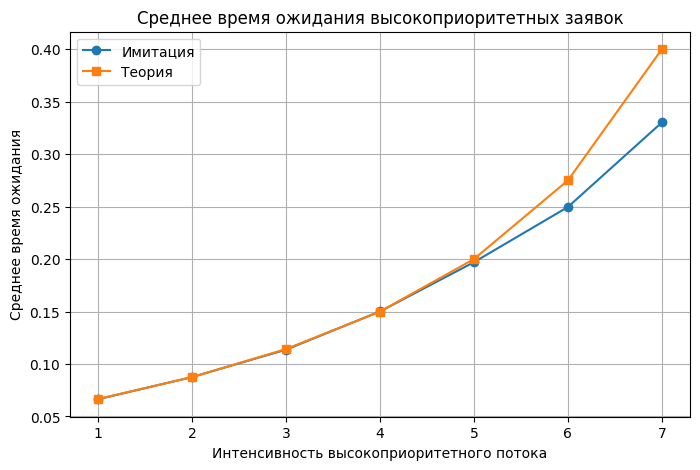

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(df_priority["lambda_high"], df_priority["Wq_high_sim"], marker="o", label="Имитация")
plt.plot(df_priority["lambda_high"], df_priority["Wq_high_theory"], marker="s", label="Теория")
plt.xlabel("Интенсивность высокоприоритетного потока")
plt.ylabel("Среднее время ожидания")
plt.title("Среднее время ожидания высокоприоритетных заявок")
plt.grid(True)
plt.legend()
plt.show()

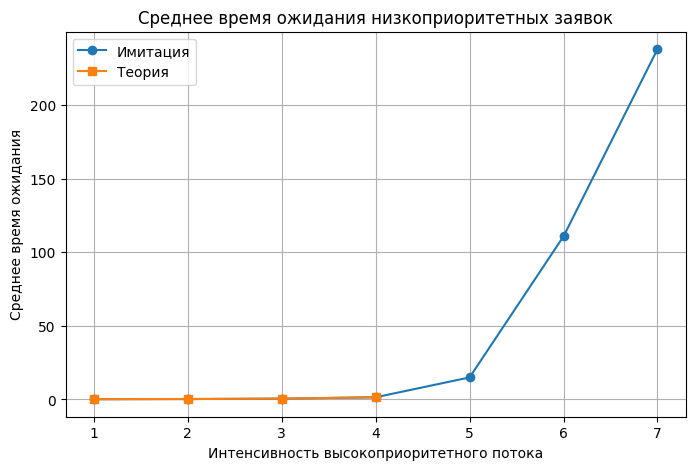

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(df_priority["lambda_high"], df_priority["Wq_low_sim"], marker="o", label="Имитация")
plt.plot(df_priority["lambda_high"], df_priority["Wq_low_theory"], marker="s", label="Теория")
plt.xlabel("Интенсивность высокоприоритетного потока")
plt.ylabel("Среднее время ожидания")
plt.title("Среднее время ожидания низкоприоритетных заявок")
plt.grid(True)
plt.legend()
plt.show()

## Анализ результатов

При увеличении интенсивности потока высокоприоритетных заявок возрастает среднее время ожидания как для высокоприоритетных, так и для низкоприоритетных звонков.  
Однако рост времени ожидания для низкоприоритетных заявок выражен значительно сильнее, так как они обслуживаются только после отсутствия заявок высокого приоритета.

Высокоприоритетные звонки получают преимущество в обслуживании, что сокращает их среднее время ожидания по сравнению с низкоприоритетными звонками.  
Низкоприоритетные заявки испытывают дополнительную задержку из-за приоритетного доступа другого класса к серверу.

Сравнение теоретических и имитационных результатов показывает их близость, что подтверждает корректность построенной модели.

## Выводы

В данной работе была исследована система массового обслуживания с абсолютным приоритетом для двух классов заявок.  
В качестве практического примера рассмотрен колл-центр с одним оператором, обслуживающим высокоприоритетные и низкоприоритетные звонки.

В результате моделирования были определены:

- среднее время ожидания в очереди для каждого класса заявок;
- среднее время пребывания в системе для каждого класса заявок;
- вероятность ожидания для каждого класса заявок;
- коэффициент загрузки системы;
- среднее число заявок в системе.

По результатам анализа установлено:

1. Высокоприоритетные заявки имеют меньшее среднее время ожидания и меньшее среднее время пребывания в системе.
2. Низкоприоритетные заявки обслуживаются с большей задержкой, поскольку уступают высокоприоритетным.
3. При увеличении интенсивности потока высокоприоритетных заявок время ожидания низкоприоритетных заявок возрастает наиболее существенно.
4. Теоретические и имитационные результаты близки друг к другу, что подтверждает корректность модели.

Следовательно, использование приоритетов позволяет улучшить качество обслуживания наиболее важных заявок, однако это приводит к ухудшению характеристик обслуживания заявок низкого приоритета.